<a href="https://colab.research.google.com/github/maheshshinde3315-arch/Code-Alpha-Tasks/blob/main/DataScienceTask2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install if needed (Colab)
!pip install pandas matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

# Preview
print(df.head())

# Check info
print(df.info())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

In [ ]:
# Rename columns (clean names)
df.columns = df.columns.str.strip()

# Convert date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Remove missing values
df = df.dropna()

# Check again
print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [ ]:
# Summary statistics
print(df.describe())

# Unique regions
print(df['Region'].unique())

                                Date  Estimated Unemployment Rate (%)  \
count                            267                       267.000000   
mean   2020-06-16 09:15:30.337078528                        12.236929   
min              2020-01-31 00:00:00                         0.500000   
25%              2020-03-31 00:00:00                         4.845000   
50%              2020-06-30 00:00:00                         9.650000   
75%              2020-08-31 00:00:00                        16.755000   
max              2020-10-31 00:00:00                        75.850000   
std                              NaN                        10.803283   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        2.670000e+02                               267.000000   
mean         1.396211e+07                                41.681573   
min          1.175420e+05                                16.770000   
25%          2.838930e+06                                37.26

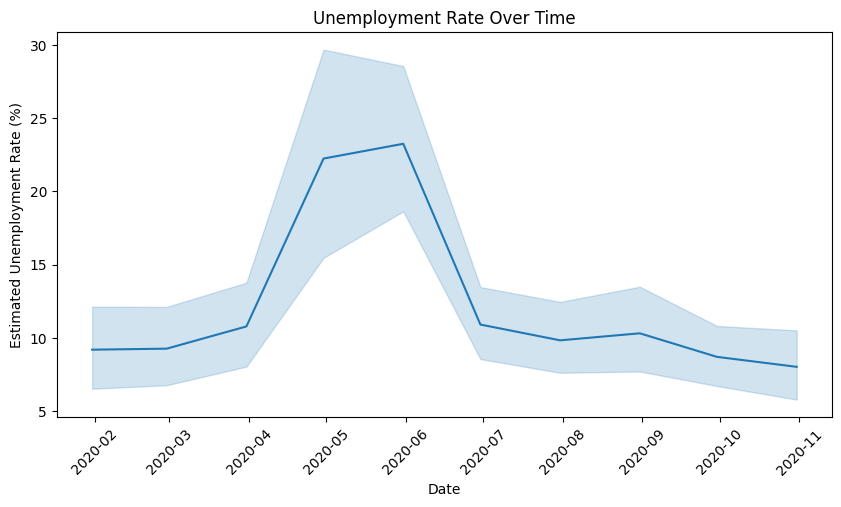

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Unemployment Rate Over Time")
plt.xticks(rotation=45)
plt.show()

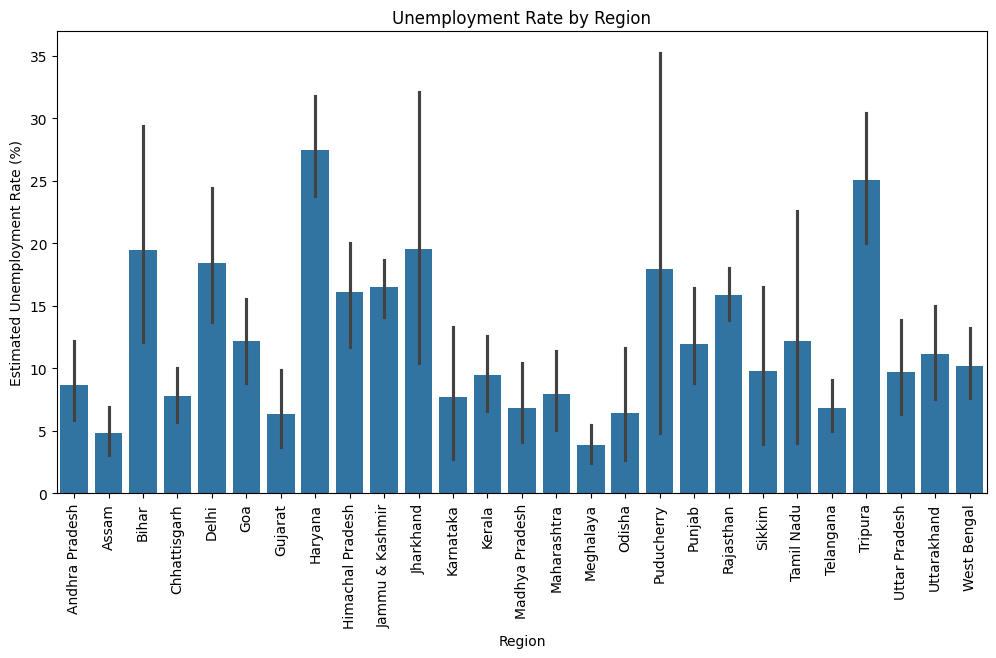

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.title("Unemployment Rate by Region")
plt.show()

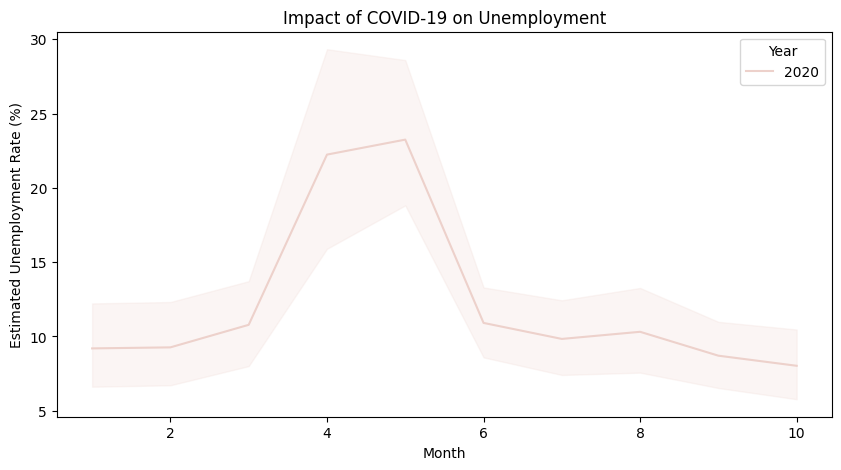

In [ ]:
# Extract month & year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Compare 2019 vs 2020
covid_df = df[df['Year'].isin([2019, 2020])]

plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Estimated Unemployment Rate (%)', hue='Year', data=covid_df)
plt.title("Impact of COVID-19 on Unemployment")
plt.show()

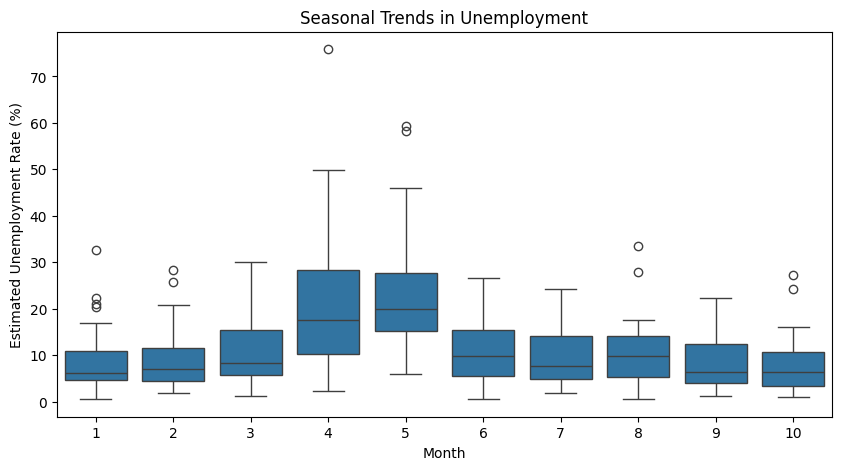

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Seasonal Trends in Unemployment")
plt.show()

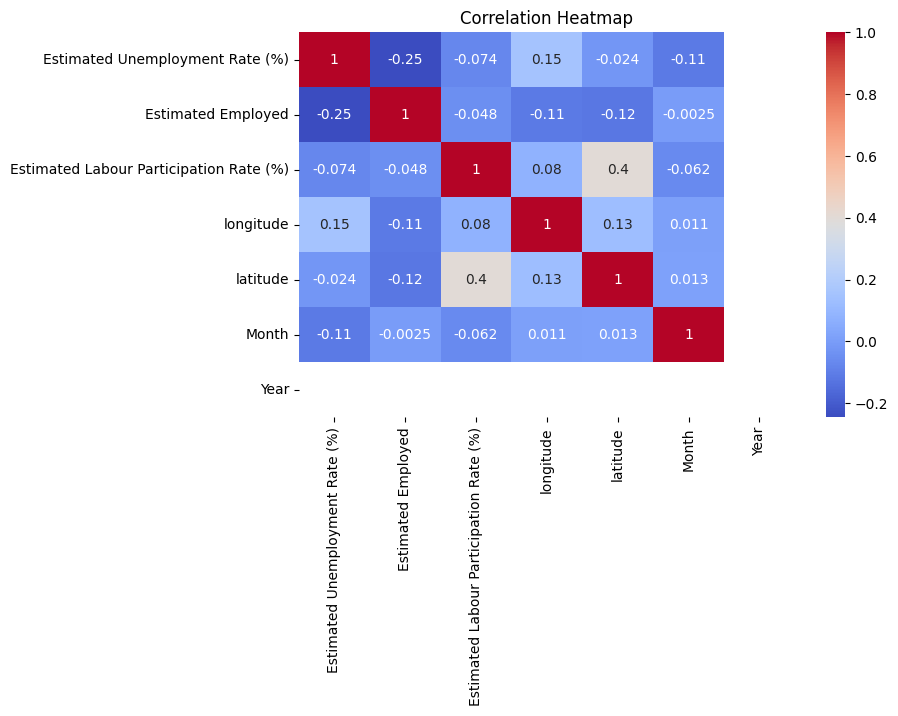

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Average Unemployment Rate:", df['Estimated Unemployment Rate (%)'].mean())

print("Highest Unemployment Region:")
print(df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head())

print("Lowest Unemployment Region:")
print(df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values().head())

Average Unemployment Rate: 12.236928838951311
Highest Unemployment Region:
Region
Haryana      27.477
Tripura      25.055
Jharkhand    19.539
Bihar        19.471
Delhi        18.414
Name: Estimated Unemployment Rate (%), dtype: float64
Lowest Unemployment Region:
Region
Meghalaya    3.866
Assam        4.856
Gujarat      6.376
Odisha       6.462
Telangana    6.833
Name: Estimated Unemployment Rate (%), dtype: float64
